In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn import metrics

chemin = 'BD_2016_2020_TableauDynamique.xlsx'
df = pd.read_excel(chemin, sheet_name="Extraction juin 2016 juin 2020")

# Renommer les colonnes : supprimer espaces, flèches, caractères spéciaux
import re

def clean_column_name(col):
    """Nettoie le nom de colonne : supprime espaces, flèches, caractères spéciaux"""
    # Remplacer les flèches par underscore
    col = col.replace('->', '_')
    col = col.replace('→', '_')
    # Remplacer les espaces par underscore
    col = col.replace(' ', '_')
    # Supprimer les caractères spéciaux
    col = re.sub(r'[^a-zA-Z0-9_]', '', col)
    # Supprimer les underscores multiples
    col = re.sub(r'_+', '_', col)
    # Transformer en minuscules
    col = col.lower()
    return col

df.columns = [clean_column_name(col) for col in df.columns]
print("Colonnes renommées :")
print(df.columns.tolist())

Colonnes renommées :
['num_dordre', 'date', 'heure', '_informations_du_passage_date_et_heure_darrive', '_informations_du_passage_moyen_darrive', '_iao_motif_dentre', '_iao_motif_de_venue', '_patient_age_en_anne', '_antcdent_antcdents_mdicaux', '_antcdent_antcdents_chirurgicaux', '_constante_surveillances_paspad_adultes_premire_valeur', '_constante_surveillances_fc_adultes_premire_valeur', '_constante_surveillances_temprature_adultes_premire_valeur', '_constante_surveillances_sao2_adultes_premire_valeur', '_constante_surveillances_frquence_respiratoire_premire_valeur', '_diagnostic_code_ccmu', '_localisation_salles', '_localisation_date_dentre_en_box', '_anamnse_texte', '_iao_observation', '_examens_complmentaires_a_des_examens_de_biologie', '_examens_complmentaires_a_des_examens_de_radiologie', '_examens_complmentaires_a_des_examens_dchographie', '_examens_complmentaires_a_des_examens_de_scanner', '_examens_complmentaires_a_des_examens_dirm', '_examens_complmentaires_a_des_avis_de_spci

In [7]:
# =========================================
# CHUNK 2 — Parsing datetime robuste (mix)
# =========================================
def parse_dt_mixed(s: pd.Series) -> pd.Series:
    """
    Parse dates potentiellement mixtes:
    - strings datetime (ex: '2020-01-01 12:34')
    - serial Excel (float/int) jours depuis 1899-12-30
    """
    s0 = s.copy()
    dt = pd.to_datetime(s0, errors="coerce")

    mask = dt.isna() & s0.notna()
    if mask.any():
        num = pd.to_numeric(s0[mask], errors="coerce")
        dt2 = pd.to_datetime(num, unit="D", origin=EXCEL_ORIGIN, errors="coerce")
        dt.loc[mask] = dt2

    return dt

# Colonnes datetime utiles (selon ta liste)
df["arrive_dt"] = parse_dt_mixed(df["_informations_du_passage_date_et_heure_darrive"])
df["pec_dt"]    = parse_dt_mixed(df["_informations_du_passage_date_dbut_prise_en_charge_mdicale"])
df["box_dt"]    = parse_dt_mixed(df["_localisation_date_dentre_en_box"])
df["sortie_dt"] = parse_dt_mixed(df["_informations_du_passage_date_et_heure_de_sortie"])

# Bio (optionnel mais utile)
df["bio_presc_dt"] = parse_dt_mixed(df["_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie"])
df["bio_samp_dt"]  = parse_dt_mixed(df["_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie"])

print(df[["arrive_dt","pec_dt","box_dt","sortie_dt"]].isna().mean().round(3))

arrive_dt    0.000
pec_dt       0.114
box_dt       0.444
sortie_dt    0.000
dtype: float64


In [8]:
# ============================================================
# S0 — BASELINE (sans IoT)
# Objectif : calculer les KPI de parcours à partir des colonnes réelles,
# puis produire les distributions/plots qui serviront de référence.
#
# Conseils (rapport) :
# - Séparer clairement "données observées" vs "scénarios simulés"
# - Nettoyer les durées négatives/absurdes (erreurs de saisie/format)
# - Se concentrer sur le sous-ensemble "hospitalisés aval" pour l'effet lits
#   (c’est là que l'IoT lits + dashboard est censé apporter le plus).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = df.copy()

# -----------------------------
# 1) Parsing des dates (important)
# -----------------------------
df["arrive_dt"] = pd.to_datetime(df["_informations_du_passage_date_et_heure_darrive"], errors="coerce")

df["sortie_dt"] = pd.to_datetime(
    df["_informations_du_passage_date_et_heure_de_sortie"],
    unit="D", origin="1899-12-30", errors="coerce"
)

df["pec_dt"] = pd.to_datetime(
    df["_informations_du_passage_date_dbut_prise_en_charge_mdicale"],
    unit="D", origin="1899-12-30", errors="coerce"
)

df["box_dt"] = pd.to_datetime(
    df["_localisation_date_dentre_en_box"],
    unit="D", origin="1899-12-30", errors="coerce"
)

# -----------------------------
# 2) Durées baseline (minutes)
# -----------------------------
df["t_arrive_sortie_min"] = (df["sortie_dt"] - df["arrive_dt"]).dt.total_seconds() / 60
df["t_arrive_pec_min"]    = (df["pec_dt"]   - df["arrive_dt"]).dt.total_seconds() / 60
df["t_arrive_box_min"]    = (df["box_dt"]   - df["arrive_dt"]).dt.total_seconds() / 60
df["t_pec_sortie_min"]    = (df["sortie_dt"]- df["pec_dt"]).dt.total_seconds() / 60

# Nettoyage minimum : durées négatives -> NaN
# (souvent anomalies de saisie, ou conversions incorrectes)
for c in ["t_arrive_sortie_min","t_arrive_pec_min","t_arrive_box_min","t_pec_sortie_min"]:
    df.loc[df[c] < 0, c] = np.nan

# -----------------------------
# 3) Features temporelles (pics 22h–2h)
# -----------------------------
df["hour"]  = df["arrive_dt"].dt.hour
df["dow"]   = df["arrive_dt"].dt.dayofweek
df["month"] = df["arrive_dt"].dt.month

# -----------------------------
# 4) Définir "hospitalisation aval" 
# -----------------------------
# Ici : TRANSFERT INTERNE = hospitalisation (aval).
df["is_hosp_aval"] = df["_orientation_type_dorientation"].astype(str).str.contains("TRANSFERT INTERNE", na=False)

# Sous-ensemble utile pour l'impact "lits aval"
mask_hosp = df["is_hosp_aval"] & df["t_arrive_sortie_min"].notna()
df_hosp = df.loc[mask_hosp].copy()

print("Baseline - nb hospitalisés aval :", len(df_hosp))
print(df_hosp["t_arrive_sortie_min"].describe(percentiles=[.5,.9,.95]))

Baseline - nb hospitalisés aval : 67310
count     67310.000000
mean        939.187818
std        2285.208591
min           1.000000
50%         512.000000
90%        1812.000000
95%        3044.000000
max      313899.000000
Name: t_arrive_sortie_min, dtype: float64


In [9]:
# ============================================================
# S1 — IoT LITS + DASHBOARD (gain proportionnel plutôt que résidu logistique)
#
# - On simule l’apport de l’IoT lits + dashboard comme une réduction
#   PROPORTIONNELLE de la durée totale Arrivée→Sortie pour les patients
#   concernés (ici : hospitalisés aval).
# - Interprétation : l’IoT réduit une FRACTION du temps perdu en coordination,
#   appels, itérations, incertitude et désynchronisation (et pas un delta fixe).
# ============================================================

import numpy as np
import pandas as pd

# On part de df_hosp construit en S0 : doit contenir au minimum t_arrive_sortie_min + hour
# ici on n'a plus besoin de t_arrive_pec_min / t_pec_sortie_min pour simuler l'effet IoT lits+dashboard
d = df_hosp[["t_arrive_sortie_min", "hour"]].dropna().copy()

# --------------------------------------------
# 0) Nettoyage minimal
# --------------------------------------------
# certaines durées sont aberrantes (ex: 313899 min) -> elles écrasent les stats.
# Deux options :
#   A) Conserver la brute pour transparence + faire des visus aussi en "cap 48h"
#   B) Travailler uniquement sur une fenêtre opérationnelle (<= 48h)
#
# Ici, je conserve la brute ET je crée une version capée à 48h (2880 min) pour des plots stables.
d["t_arrive_sortie_min_cap48h"] = d["t_arrive_sortie_min"].clip(upper=2880)

# --------------------------------------------
# 1) Fonction de simulation (gain proportionnel)
# --------------------------------------------
def simulate_iot_beds_dashboard_pct(
    df_sub: pd.DataFrame,
    pct_gain: float = 0.06,   # ex: 6% de réduction
    use_capped: bool = False  # si True -> calcule sur la colonne cap48h (utile pour graphes)
) -> pd.DataFrame:
    """
    pct_gain : fraction de réduction (0.06 = -6%).
    Conseils :
    - Tester plusieurs % (sensibilité) : 0.03, 0.06, 0.10
    - pct_gain doit rester raisonnable (sinon ça ressemble à une "magie").
    - Option use_capped : utile pour visualiser sans être dominé par les extrêmes.
    """
    out = df_sub.copy()
    out["pct_gain_iot_beds_dashboard"] = pct_gain

    base_col = "t_arrive_sortie_min_cap48h" if use_capped else "t_arrive_sortie_min"

    # Réduction proportionnelle (borne lower=1 min pour éviter 0/neg)
    out["t_arrive_sortie_min_iot"] = (out[base_col] * (1 - pct_gain)).clip(lower=1)

    # Gain obtenu (min) -> utile pour tableaux / discussions
    out["gain_min"] = (out[base_col] - out["t_arrive_sortie_min_iot"]).clip(lower=0)

    return out

# --------------------------------------------
# 2) Scénarios à tester (sensibilité)
# --------------------------------------------
# 3 scénarios :
# - IoT info seule (petit gain)
# - IoT + dashboard (gain moyen)
# - (ordonnanceur = S2, plus tard) (gain plus fort)
scenarios_pct = {
    "IoT_info_seule_3pct": 0.03,
    "IoT+dashboard_6pct": 0.06,
    "IoT+dashboard_10pct": 0.10,
}

sim_s1 = {}
for name, pct in scenarios_pct.items():
    sim_s1[name] = simulate_iot_beds_dashboard_pct(d, pct_gain=pct, use_capped=False)

# --------------------------------------------
# 3) Impression de quantiles (sur la brute)
# --------------------------------------------
# Conseil : regarde surtout p90/p95 + parts >8h / >12h
q = [0.5, 0.9, 0.95]
print("Baseline quantiles :", d["t_arrive_sortie_min"].quantile(q))

for name, sim in sim_s1.items():
    print(f"{name} quantiles :", sim["t_arrive_sortie_min_iot"].quantile(q))

# --------------------------------------------
# 4) KPI complémentaires (preuves IoT)
# --------------------------------------------
# - part des séjours > 8h, > 12h
# - gain médian + gain P95 (en minutes)
baseline_over_8h = (d["t_arrive_sortie_min"] > 8*60).mean()
baseline_over_12h = (d["t_arrive_sortie_min"] > 12*60).mean()
print("Baseline >8h:", baseline_over_8h, " / >12h:", baseline_over_12h)

for name, sim in sim_s1.items():
    over_8h = (sim["t_arrive_sortie_min_iot"] > 8*60).mean()
    over_12h = (sim["t_arrive_sortie_min_iot"] > 12*60).mean()
    print(
        f"{name} | gain_med={sim['gain_min'].median():.1f} min"
        f" | gain_p95={sim['gain_min'].quantile(0.95):.1f} min"
        f" | >8h={over_8h:.3f} | >12h={over_12h:.3f}"
    )

# --------------------------------------------
# 5) focus sur le pic 22h–2h 
# --------------------------------------------
# montrer que l’effet est plus visible pendant les pics.
peak_hours = [22, 23, 0, 1, 2]
d_peak = d[d["hour"].isin(peak_hours)].copy()

print("\n--- Focus 22h–2h ---")
print("Baseline peak quantiles:", d_peak["t_arrive_sortie_min"].quantile(q))

for name, sim in sim_s1.items():
    sim_peak = sim[sim["hour"].isin(peak_hours)]
    print(f"{name} peak quantiles:", sim_peak["t_arrive_sortie_min_iot"].quantile(q))

Baseline quantiles : 0.50     512.0
0.90    1812.0
0.95    3044.0
Name: t_arrive_sortie_min, dtype: float64
IoT_info_seule_3pct quantiles : 0.50     496.64
0.90    1757.64
0.95    2952.68
Name: t_arrive_sortie_min_iot, dtype: float64
IoT+dashboard_6pct quantiles : 0.50     481.28
0.90    1703.28
0.95    2861.36
Name: t_arrive_sortie_min_iot, dtype: float64
IoT+dashboard_10pct quantiles : 0.50     460.8
0.90    1630.8
0.95    2739.6
Name: t_arrive_sortie_min_iot, dtype: float64
Baseline >8h: 0.5367255979794978  / >12h: 0.3351359381964047
IoT_info_seule_3pct | gain_med=15.4 min | gain_p95=91.3 min | >8h=0.520 | >12h=0.324
IoT+dashboard_6pct | gain_med=30.7 min | gain_p95=182.6 min | >8h=0.501 | >12h=0.313
IoT+dashboard_10pct | gain_med=51.2 min | gain_p95=304.4 min | >8h=0.476 | >12h=0.300

--- Focus 22h–2h ---
Baseline peak quantiles: 0.50     578.0
0.90    2307.0
0.95    3574.1
Name: t_arrive_sortie_min, dtype: float64
IoT_info_seule_3pct peak quantiles: 0.50     560.660
0.90    2237.7

In [10]:
# ============================================================
# S2 — IoT + ORDONNANCEUR (gain proportionnel dépendant de la tension)
#
# Modélisation retenue :
# 1) On estime une "tension" par HEURE D’ARRIVÉE à partir d’un proxy observable :
#    - volume d’arrivées par heure (fréquence) OU
#    - durée médiane Arrivée→Sortie par heure (plus long = plus tendu)
#
# 2) L'ordonnanceur apporte un gain additionnel surtout en surcharge :
#    - Gain_total_pct = base_pct + extra_pct * tension(hour)
#      où tension(hour) ∈ [0,1]
#
# - base_pct : bénéfice minimal (IoT info temps réel / dashboard)
# - extra_pct : bénéfice additionnel de l’ordonnanceur quand le système est tendu
#
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) Données d'entrée
# ------------------------------------------------------------
# On part de df_hosp construit en S0 (hospitalisés aval) et du dataframe "d" de S1 :
# d doit contenir :
# - t_arrive_sortie_min (durée brute)
# - hour (heure d'arrivée)

# ------------------------------------------------------------
# 1) Proxy de tension par heure : 2 options (choisis-en 1 ou combine)
# ------------------------------------------------------------

# OPTION A (très simple et robuste) : tension = volume relatif d'arrivées par heure
# -> plus il y a d'arrivées à cette heure, plus le système est "chargé"
hour_counts = d.groupby("hour").size()

# OPTION B (souvent très parlant) : tension = durée médiane observée par heure
# -> si la médiane Arrivée→Sortie est plus haute à certaines heures, on considère que c'est plus tendu
hour_median_los = d.groupby("hour")["t_arrive_sortie_min"].median()

# Normalisation 0-1 (évite division par 0)
def normalize_0_1(s: pd.Series) -> pd.Series:
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

tension_counts_0_1 = normalize_0_1(hour_counts)
tension_los_0_1 = normalize_0_1(hour_median_los)

# CONSEIL : pour une tension plus stable, tu peux faire une moyenne pondérée des deux proxies.
# Ici 50/50 (tu peux ajuster).
tension_0_1 = 0.5 * tension_counts_0_1 + 0.5 * tension_los_0_1

# Vérification : tension bien dans [0,1]
print("Tension min/max:", float(tension_0_1.min()), float(tension_0_1.max()))
print("Heures les plus tendues (top 5):")
print(tension_0_1.sort_values(ascending=False).head(5))

# ------------------------------------------------------------
# 2) Simulation ordonnanceur : gain proportionnel dépendant de la tension
# ------------------------------------------------------------
def simulate_iot_with_scheduler_pct(
    df_sub: pd.DataFrame,
    base_pct: float = 0.06,   # bénéfice "IoT + dashboard" minimal (ex : 6%)
    extra_pct: float = 0.06,  # bénéfice additionnel max en surcharge (ex : +6% -> total 12% quand tension=1)
    use_capped: bool = False  # optionnel : travailler sur une colonne cap48h pour des graphes stables
) -> pd.DataFrame:
    """
    Gain_total_pct = base_pct + extra_pct * tension(hour)

    Conseils :
    - base_pct correspond à l'effet "dashboard" qu'on a simulé en S1.
    - extra_pct modélise ce que l’ordonnanceur apporte en plus :
      priorisation, réduction itérations, allocations plus rapides en pic.
    - Garder des pourcentages raisonnables (sinon ça ressemble à de la magie).
    - Optionnel : faire une analyse de sensibilité sur extra_pct (0.03 / 0.06 / 0.10).
    """
    out = df_sub.copy()
    out["tension_0_1"] = out["hour"].map(tension_0_1).fillna(0.0)

    out["pct_gain_total"] = base_pct + extra_pct * out["tension_0_1"]

    base_col = "t_arrive_sortie_min_cap48h" if (use_capped and "t_arrive_sortie_min_cap48h" in out.columns) else "t_arrive_sortie_min"

    # Application du gain proportionnel
    out["t_arrive_sortie_min_iot_sched"] = (out[base_col] * (1 - out["pct_gain_total"])).clip(lower=1)

    # Gain en minutes (utile pour KPI)
    out["gain_min_sched"] = (out[base_col] - out["t_arrive_sortie_min_iot_sched"]).clip(lower=0)

    return out

# Exemple : IoT+dashboard base 6% + ordonnanceur extra 6% * tension
sim_s2 = simulate_iot_with_scheduler_pct(d, base_pct=0.06, extra_pct=0.06, use_capped=False)

# ------------------------------------------------------------
# 3) Résultats : quantiles + KPI >8h / >12h (preuves IoT)
# ------------------------------------------------------------
q = [0.5, 0.9, 0.95]
print("\nBaseline quantiles:", d["t_arrive_sortie_min"].quantile(q))
print("S2 (IoT+ordonnanceur) quantiles:", sim_s2["t_arrive_sortie_min_iot_sched"].quantile(q))

baseline_over_8h = (d["t_arrive_sortie_min"] > 8*60).mean()
baseline_over_12h = (d["t_arrive_sortie_min"] > 12*60).mean()
s2_over_8h = (sim_s2["t_arrive_sortie_min_iot_sched"] > 8*60).mean()
s2_over_12h = (sim_s2["t_arrive_sortie_min_iot_sched"] > 12*60).mean()

print("\nKPI >8h baseline:", baseline_over_8h, " / S2:", s2_over_8h)
print("KPI >12h baseline:", baseline_over_12h, " / S2:", s2_over_12h)

print("\nGain médian (min):", sim_s2["gain_min_sched"].median())
print("Gain p95 (min):", sim_s2["gain_min_sched"].quantile(0.95))

# ------------------------------------------------------------
# 4) Focus pic 22h–2h (cohérence CHU Lille)
# ------------------------------------------------------------
peak_hours = [22, 23, 0, 1, 2]
d_peak = d[d["hour"].isin(peak_hours)].copy()
s2_peak = sim_s2[sim_s2["hour"].isin(peak_hours)].copy()

print("\n--- Focus 22h–2h ---")
print("Baseline peak quantiles:", d_peak["t_arrive_sortie_min"].quantile(q))
print("S2 peak quantiles:", s2_peak["t_arrive_sortie_min_iot_sched"].quantile(q))

Tension min/max: 0.1799757894220984 0.6956521738126248
Heures les plus tendues (top 5):
hour
11    0.695652
12    0.687631
15    0.683828
14    0.683178
13    0.657924
dtype: float64

Baseline quantiles: 0.50     512.0
0.90    1812.0
0.95    3044.0
Name: t_arrive_sortie_min, dtype: float64
S2 (IoT+ordonnanceur) quantiles: 0.50     463.468986
0.90    1641.648136
0.95    2739.962286
Name: t_arrive_sortie_min_iot_sched, dtype: float64

KPI >8h baseline: 0.5367255979794978  / S2: 0.4799732580597237
KPI >12h baseline: 0.3351359381964047  / S2: 0.3025553409597385

Gain médian (min): 48.32702943741475
Gain p95 (min): 294.2694981420112

--- Focus 22h–2h ---
Baseline peak quantiles: 0.50     578.0
0.90    2307.0
0.95    3574.1
Name: t_arrive_sortie_min, dtype: float64
S2 peak quantiles: 0.50     529.135187
0.90    2112.078183
0.95    3265.394007
Name: t_arrive_sortie_min_iot_sched, dtype: float64


Nb combinaisons testées: 420
       mode  alpha  base_pct  extra_pct   gain_q50    gain_q95  gain_over8_pp  \
419     mix   1.00      0.10       0.12  98.628566  778.606360      11.708513   
239  counts    NaN      0.10       0.12  98.628566  778.606360      11.708513   
389     mix   0.75      0.10       0.12  92.306901  735.748855      11.002823   
238  counts    NaN      0.10       0.10  90.819490  727.972158      10.750260   
418     mix   1.00      0.10       0.10  90.819490  727.972158      10.750260   
413     mix   1.00      0.08       0.12  88.208668  723.256382      10.465013   
233  counts    NaN      0.08       0.12  88.208668  723.256382      10.465013   
359     mix   0.50      0.10       0.12  86.147258  689.645177      10.307532   
388     mix   0.75      0.10       0.10  85.373716  688.457379      10.145595   
383     mix   0.75      0.08       0.12  82.031396  678.148855       9.766751   

     gain_over12_pp  peak_gain_q95  
419        5.493983    1091.473179  
239  

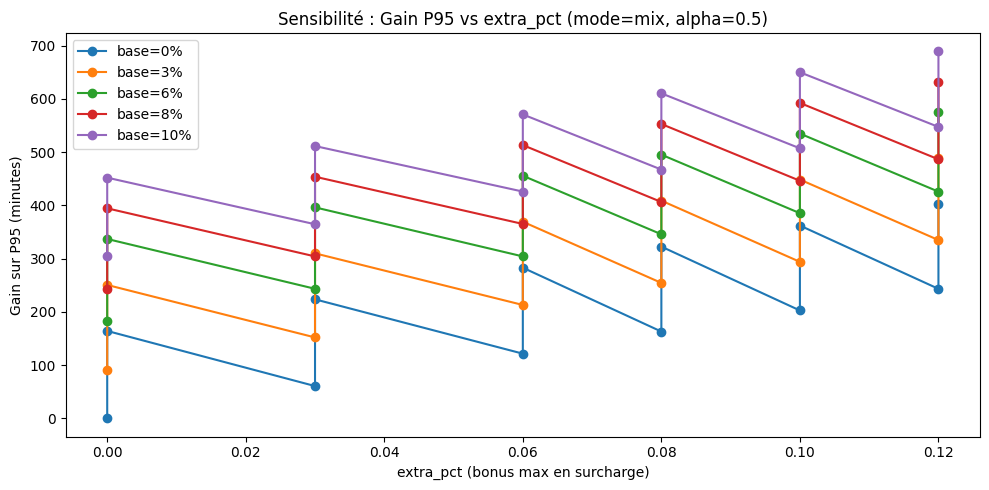

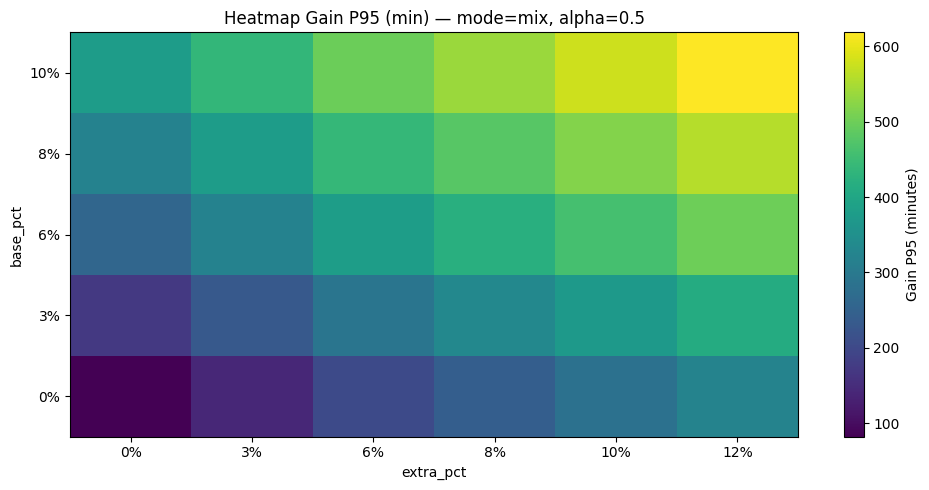

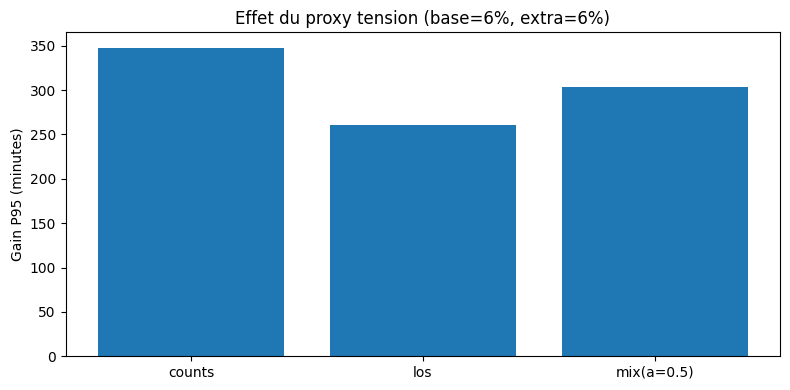

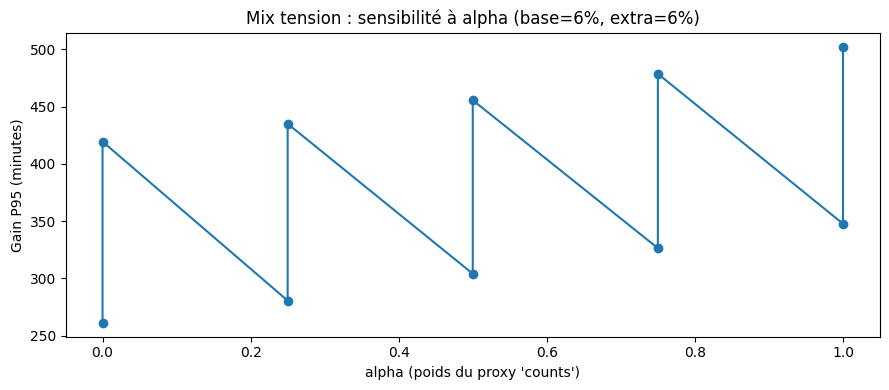

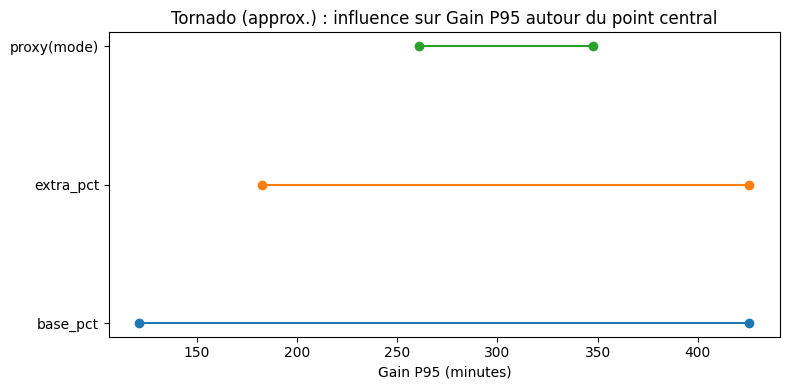

In [11]:
# ============================================================
# SENSITIVITÉ S2 — balayage des paramètres + graphiques
# Objectif :
# - faire varier tout ce qui est "réglable"
# - mesurer l'effet sur des KPI
# - visualiser l'influence : lignes + heatmaps + tornado
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Helpers
# ----------------------------
def normalize_0_1(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

def build_tension_series(d: pd.DataFrame, mode: str = "mix", alpha: float = 0.5) -> pd.Series:
    """
    mode:
      - "counts" : tension = volume d'arrivées par heure
      - "los"    : tension = durée médiane Arrivée→Sortie par heure
      - "mix"    : tension = alpha*counts + (1-alpha)*los
    alpha:
      - poids de counts (0..1) si mode="mix"
    """
    hour_counts = d.groupby("hour").size()
    hour_median_los = d.groupby("hour")["t_arrive_sortie_min"].median()

    t_counts = normalize_0_1(hour_counts)
    t_los = normalize_0_1(hour_median_los)

    if mode == "counts":
        tension = t_counts
    elif mode == "los":
        tension = t_los
    elif mode == "mix":
        tension = alpha * t_counts + (1 - alpha) * t_los
    else:
        raise ValueError("mode must be 'counts', 'los', or 'mix'")

    # sécurise [0,1] (numériquement)
    return tension.clip(0, 1)

def simulate_iot_with_scheduler_pct(df_sub: pd.DataFrame, tension_0_1: pd.Series,
                                   base_pct: float, extra_pct: float,
                                   use_capped: bool = False) -> pd.DataFrame:
    """
    Gain_total_pct = base_pct + extra_pct * tension(hour)
    """
    out = df_sub.copy()
    out["tension_0_1"] = out["hour"].map(tension_0_1).fillna(0.0)
    out["pct_gain_total"] = base_pct + extra_pct * out["tension_0_1"]

    base_col = "t_arrive_sortie_min_cap48h" if (use_capped and "t_arrive_sortie_min_cap48h" in out.columns) else "t_arrive_sortie_min"

    out["t_arrive_sortie_min_iot_sched"] = (out[base_col] * (1 - out["pct_gain_total"])).clip(lower=1)
    out["gain_min_sched"] = (out[base_col] - out["t_arrive_sortie_min_iot_sched"]).clip(lower=0)
    return out

def compute_kpis(base: pd.Series, scen: pd.Series) -> dict:
    q50 = float(scen.quantile(0.50))
    q90 = float(scen.quantile(0.90))
    q95 = float(scen.quantile(0.95))
    over8 = float((scen > 8*60).mean())
    over12 = float((scen > 12*60).mean())

    bq50 = float(base.quantile(0.50))
    bq90 = float(base.quantile(0.90))
    bq95 = float(base.quantile(0.95))
    bover8 = float((base > 8*60).mean())
    bover12 = float((base > 12*60).mean())

    return {
        "q50": q50, "q90": q90, "q95": q95,
        "over8": over8, "over12": over12,
        "gain_q50": bq50 - q50,
        "gain_q90": bq90 - q90,
        "gain_q95": bq95 - q95,
        "gain_over8_pp": (bover8 - over8) * 100,    # points de %
        "gain_over12_pp": (bover12 - over12) * 100, # points de %
    }

# ----------------------------
# 1) Paramètres à faire varier
# ----------------------------
# NOTE : commence "raisonnable", puis élargis si besoin
base_pcts  = [0.00, 0.03, 0.06, 0.08, 0.10]          # bénéfice minimal
extra_pcts = [0.00, 0.03, 0.06, 0.08, 0.10, 0.12]    # bonus max en tension
modes      = ["counts", "los", "mix"]                # proxy tension
alphas     = [0.0, 0.25, 0.5, 0.75, 1.0]             # mix : poids counts (0->100%)
use_capped_list = [False, True]                      # si tu as cap48h

peak_hours = [22, 23, 0, 1, 2]
base_series = d["t_arrive_sortie_min"].dropna()

# ----------------------------
# 2) Exécuter le balayage (grid)
# ----------------------------
rows = []

for use_capped in use_capped_list:
    if use_capped and ("t_arrive_sortie_min_cap48h" not in d.columns):
        # si la colonne n'existe pas, on saute cette option
        continue

    for mode in modes:
        # alphas uniquement utiles si mix, sinon on fixe alpha à NaN
        alpha_list = alphas if mode == "mix" else [np.nan]

        for alpha in alpha_list:
            tension = build_tension_series(d, mode=mode, alpha=0.5 if np.isnan(alpha) else float(alpha))

            for base_pct in base_pcts:
                for extra_pct in extra_pcts:
                    sim = simulate_iot_with_scheduler_pct(d, tension, base_pct, extra_pct, use_capped=use_capped)

                    k = compute_kpis(base_series, sim["t_arrive_sortie_min_iot_sched"])

                    # focus pic
                    base_peak = d.loc[d["hour"].isin(peak_hours), "t_arrive_sortie_min"].dropna()
                    scen_peak = sim.loc[sim["hour"].isin(peak_hours), "t_arrive_sortie_min_iot_sched"].dropna()
                    peak_gain_q95 = float(base_peak.quantile(0.95) - scen_peak.quantile(0.95))

                    rows.append({
                        "use_capped": use_capped,
                        "mode": mode,
                        "alpha": alpha,
                        "base_pct": base_pct,
                        "extra_pct": extra_pct,
                        **k,
                        "peak_gain_q95": peak_gain_q95
                    })

res = pd.DataFrame(rows)

print("Nb combinaisons testées:", len(res))
print(res.sort_values("gain_q95", ascending=False).head(10)[
    ["mode","alpha","base_pct","extra_pct","gain_q50","gain_q95","gain_over8_pp","gain_over12_pp","peak_gain_q95"]
])

# ----------------------------
# 3) GRAPHIQUE 1 — Courbes : gain P95 vs extra_pct (pour plusieurs base_pct)
# ----------------------------
# On fixe un mode et un alpha pour lire facilement (tu peux changer)
mode_focus = "mix"
alpha_focus = 0.5

tmp = res[(res["mode"] == mode_focus) & (res["alpha"].fillna(alpha_focus) == alpha_focus)].copy()
tmp = tmp.sort_values(["base_pct","extra_pct"])

plt.figure(figsize=(10,5))
for b in base_pcts:
    sub = tmp[tmp["base_pct"] == b]
    if len(sub) == 0:
        continue
    plt.plot(sub["extra_pct"], sub["gain_q95"], marker="o", label=f"base={b:.0%}")
plt.xlabel("extra_pct (bonus max en surcharge)")
plt.ylabel("Gain sur P95 (minutes)")
plt.title(f"Sensibilité : Gain P95 vs extra_pct (mode={mode_focus}, alpha={alpha_focus})")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 4) GRAPHIQUE 2 — Heatmap : gain P95 (base_pct x extra_pct)
# ----------------------------
# Toujours sur le même focus (lisible)
pivot = tmp.pivot_table(index="base_pct", columns="extra_pct", values="gain_q95", aggfunc="mean")
plt.figure(figsize=(10,5))
plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.xticks(range(len(pivot.columns)), [f"{c:.0%}" for c in pivot.columns])
plt.yticks(range(len(pivot.index)), [f"{r:.0%}" for r in pivot.index])
plt.xlabel("extra_pct")
plt.ylabel("base_pct")
plt.title(f"Heatmap Gain P95 (min) — mode={mode_focus}, alpha={alpha_focus}")
plt.colorbar(label="Gain P95 (minutes)")
plt.tight_layout()
plt.show()

# ----------------------------
# 5) GRAPHIQUE 3 — Comparaison des proxies : counts vs los vs mix
# ----------------------------
# On choisit une config (base, extra) et on compare les modes
base_pick, extra_pick = 0.06, 0.06
cmp = res[(res["base_pct"] == base_pick) & (res["extra_pct"] == extra_pick)].copy()

# Pour "mix", on prend alpha=0.5 (tu peux aussi tracer gain vs alpha plus bas)
cmp_counts = cmp[cmp["mode"] == "counts"].head(1)
cmp_los    = cmp[cmp["mode"] == "los"].head(1)
cmp_mix    = cmp[(cmp["mode"] == "mix") & (cmp["alpha"] == 0.5)].head(1)

cmp_plot = pd.concat([cmp_counts, cmp_los, cmp_mix], axis=0)
labels = []
vals = []
for _, r in cmp_plot.iterrows():
    labels.append(f"{r['mode']}" + ("" if pd.isna(r["alpha"]) else f"(a={r['alpha']})"))
    vals.append(r["gain_q95"])

plt.figure(figsize=(8,4))
plt.bar(range(len(labels)), vals)
plt.xticks(range(len(labels)), labels, rotation=0)
plt.ylabel("Gain P95 (minutes)")
plt.title(f"Effet du proxy tension (base={base_pick:.0%}, extra={extra_pick:.0%})")
plt.tight_layout()
plt.show()

# ----------------------------
# 6) GRAPHIQUE 4 — Si mode=mix : gain P95 en fonction de alpha
# ----------------------------
mix = res[(res["mode"] == "mix") & (res["base_pct"] == base_pick) & (res["extra_pct"] == extra_pick)].copy()
mix = mix.sort_values("alpha")

plt.figure(figsize=(9,4))
plt.plot(mix["alpha"], mix["gain_q95"], marker="o")
plt.xlabel("alpha (poids du proxy 'counts')")
plt.ylabel("Gain P95 (minutes)")
plt.title(f"Mix tension : sensibilité à alpha (base={base_pick:.0%}, extra={extra_pick:.0%})")
plt.tight_layout()
plt.show()

# ----------------------------
# 7) GRAPHIQUE 5 — Tornado plot : influence "visuelle" des paramètres
# ----------------------------
# Idée : on regarde l'amplitude de gain_q95 quand on fait varier UN paramètre à la fois
# autour d'un point central.
center = {
    "mode": "mix",
    "alpha": 0.5,
    "base_pct": 0.06,
    "extra_pct": 0.06,
    "use_capped": False if ("t_arrive_sortie_min_cap48h" not in d.columns) else False
}

# filtre des lignes proches du centre pour comparer proprement
center_df = res.copy()
center_df = center_df[center_df["use_capped"] == center["use_capped"]]

# mode/alpha
def range_for_param(param_name, mask):
    sub = center_df[mask]
    return float(sub["gain_q95"].min()), float(sub["gain_q95"].max())

# (a) base_pct variation
mask_base = (
    (center_df["mode"] == center["mode"]) &
    (center_df["alpha"].fillna(center["alpha"]) == center["alpha"]) &
    (center_df["extra_pct"] == center["extra_pct"])
)
bmin, bmax = range_for_param("base_pct", mask_base)

# (b) extra_pct variation
mask_extra = (
    (center_df["mode"] == center["mode"]) &
    (center_df["alpha"].fillna(center["alpha"]) == center["alpha"]) &
    (center_df["base_pct"] == center["base_pct"])
)
emin, emax = range_for_param("extra_pct", mask_extra)

# (c) mode variation (fix base/extra, pick alpha=0.5 for mix)
mask_mode = (
    (center_df["base_pct"] == center["base_pct"]) &
    (center_df["extra_pct"] == center["extra_pct"]) &
    (
        (center_df["mode"].isin(["counts","los"])) |
        ((center_df["mode"] == "mix") & (center_df["alpha"] == center["alpha"]))
    )
)
mmin, mmax = range_for_param("mode", mask_mode)

params = ["base_pct", "extra_pct", "proxy(mode)"]
mins = [bmin, emin, mmin]
maxs = [bmax, emax, mmax]

# Tornado horizontal
plt.figure(figsize=(8,4))
y = np.arange(len(params))
for i in range(len(params)):
    plt.plot([mins[i], maxs[i]], [y[i], y[i]], marker="o")
plt.yticks(y, params)
plt.xlabel("Gain P95 (minutes)")
plt.title("Tornado (approx.) : influence sur Gain P95 autour du point central")
plt.tight_layout()
plt.show()

# ----------------------------
# 8) BONUS : Export des résultats pour tableau (rapport)
# ----------------------------
# res.to_csv("sensibilite_s2_results.csv", index=False)

In [ ]:
# ============================================================
# S3 — + IoT PATIENT (gain proportionnel ciblé par risque + tension)
#
# Point clé (cohérent avec ce qu’on a dit) :
# - On applique un gain PROPORTIONNEL à la durée (Arrivée→Sortie),
#   modulé par :
#   1) le RISQUE patient (faible/modéré/élevé)
#   2) la TENSION horaire (plus d’effet en période tendue)
#
# Interprétation :
# - IoT patient = amélioration de décision + anticipation + préparation
#   => réduction relative du temps total, surtout sur cas complexes.
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) Données d'entrée
# ------------------------------------------------------------

cols_needed = [
    "t_arrive_sortie_min", "hour",
    "_patient_age_en_anne",
    "_constante_surveillances_fc_adultes_premire_valeur",
    "_constante_surveillances_sao2_adultes_premire_valeur",
    "_constante_surveillances_temprature_adultes_premire_valeur",
    "_diagnostic_code_ccmu"
]

p = df.loc[df["is_hosp_aval"] & df["t_arrive_sortie_min"].notna(), cols_needed].copy()

# ------------------------------------------------------------
# 1) Parsing numérique robuste des constantes (strings hétérogènes)
# ------------------------------------------------------------
def to_num(series: pd.Series) -> pd.Series:
    """
    Conseil :
    - Beaucoup de champs sont en object avec des formats variés : "98 %", "120", "120/80", "37,2", etc.
    - On extrait le 1er nombre rencontré.
    - Si tu veux gérer les virgules françaises, on remplace ',' par '.'
    """
    s = series.astype(str).str.replace(",", ".", regex=False)
    return pd.to_numeric(s.str.extract(r"(\d+\.?\d*)")[0], errors="coerce")

p["age"]  = pd.to_numeric(p["_patient_age_en_anne"], errors="coerce")
p["fc"]   = to_num(p["_constante_surveillances_fc_adultes_premire_valeur"])
p["spo2"] = to_num(p["_constante_surveillances_sao2_adultes_premire_valeur"])
p["temp"] = to_num(p["_constante_surveillances_temprature_adultes_premire_valeur"])
p["ccmu"] = pd.to_numeric(p["_diagnostic_code_ccmu"], errors="coerce")

# ------------------------------------------------------------
# 2) Score de risque "proxy" (transparent, non clinique)
# ------------------------------------------------------------
# l’objectif n’est pas de créer un score médical validé,mais un proxy cohérent : âge, hypoxémie, tachycardie, fièvre, gravité CCMU.

# Remplissages prudents (évite NaN qui casse la logique)
age_med = p["age"].median()
p["age_f"] = p["age"].fillna(age_med)
p["spo2_f"] = p["spo2"].fillna(98)
p["fc_f"] = p["fc"].fillna(80)
p["temp_f"] = p["temp"].fillna(37)
p["ccmu_f"] = p["ccmu"].fillna(2)

p["risk_score"] = 0.0
p["risk_score"] += (p["age_f"] >= 75).astype(float) * 0.25
p["risk_score"] += (p["spo2_f"] < 92).astype(float) * 0.30
p["risk_score"] += (p["fc_f"] > 120).astype(float) * 0.20
p["risk_score"] += (p["temp_f"] >= 39).astype(float) * 0.10
p["risk_score"] += (p["ccmu_f"] >= 4).astype(float) * 0.15
p["risk_score"] = p["risk_score"].clip(0, 1)

# Catégorisation (3 niveaux)
p["risk_cat"] = pd.cut(
    p["risk_score"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["faible", "modere", "eleve"]
)

# ------------------------------------------------------------
# 3) Tension horaire (même logique que S2) : proxy observé
# ------------------------------------------------------------
# Conseil : tension = combinaison :
# - volume d’arrivées par heure
# - médiane de la durée Arrivée→Sortie par heure

def normalize_0_1(s: pd.Series) -> pd.Series:
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

hour_counts = p.groupby("hour").size()
hour_median_los = p.groupby("hour")["t_arrive_sortie_min"].median()

tension_0_1 = 0.5 * normalize_0_1(hour_counts) + 0.5 * normalize_0_1(hour_median_los)

p["tension_0_1"] = p["hour"].map(tension_0_1).fillna(0.0)

# ------------------------------------------------------------
# 4) Simulation IoT patient : gain PROPORTIONNEL modulé par le risque + tension
# ------------------------------------------------------------
# Idée :
# - base_pct_by_risk : bénéfice minimum (hors surcharge)
# - extra_pct_by_risk : bénéfice additionnel en surcharge (multiplie tension)
#
# on calibre des valeurs raisonnables :
# - faible : 2–4%
# - modéré : 5–10%
# - élevé : 10–20%

base_pct_by_risk = {"faible": 0.03, "modere": 0.08, "eleve": 0.15}
extra_pct_by_risk = {"faible": 0.01, "modere": 0.03, "eleve": 0.05}

p["base_pct"] = p["risk_cat"].astype(str).map(base_pct_by_risk).fillna(0.0)
p["extra_pct"] = p["risk_cat"].astype(str).map(extra_pct_by_risk).fillna(0.0)

# Gain total dépend de la tension (plus la tension est forte, plus l’IoT patient "aide" la coordination)
p["pct_gain_patient_total"] = (p["base_pct"] + p["extra_pct"] * p["tension_0_1"]).clip(0, 0.30)
# Conseil : clip à 30% max pour rester crédible et éviter des gains irréalistes.

p["t_arrive_sortie_min_iot_patient"] = (
    p["t_arrive_sortie_min"] * (1 - p["pct_gain_patient_total"])
).clip(lower=1)

# Gain en minutes (utile pour KPI)
p["gain_min_patient"] = (p["t_arrive_sortie_min"] - p["t_arrive_sortie_min_iot_patient"]).clip(lower=0)

# ------------------------------------------------------------
# 5) Résultats : par catégorie de risque + quantiles globaux
# ------------------------------------------------------------
q = [0.5, 0.9, 0.95]

print("\n--- Gain médian par risk_cat (min) ---")
print(p.groupby("risk_cat")["gain_min_patient"].median())

print("\nBaseline quantiles:", p["t_arrive_sortie_min"].quantile(q))
print("S3 (IoT patient) quantiles:", p["t_arrive_sortie_min_iot_patient"].quantile(q))

# KPI séjours longs (preuves utiles)
baseline_over_8h = (p["t_arrive_sortie_min"] > 8*60).mean()
baseline_over_12h = (p["t_arrive_sortie_min"] > 12*60).mean()
s3_over_8h = (p["t_arrive_sortie_min_iot_patient"] > 8*60).mean()
s3_over_12h = (p["t_arrive_sortie_min_iot_patient"] > 12*60).mean()

print("\nKPI >8h baseline:", baseline_over_8h, " / S3:", s3_over_8h)
print("KPI >12h baseline:", baseline_over_12h, " / S3:", s3_over_12h)

# ------------------------------------------------------------
# 6) Focus 22h–2h (cohérence terrain)
# ------------------------------------------------------------
peak_hours = [22, 23, 0, 1, 2]
p_peak = p[p["hour"].isin(peak_hours)].copy()

print("\n--- Focus 22h–2h ---")
print("Baseline peak quantiles:", p_peak["t_arrive_sortie_min"].quantile(q))
print("S3 peak quantiles:", p_peak["t_arrive_sortie_min_iot_patient"].quantile(q))


--- Gain médian par risk_cat (min) ---
risk_cat
faible    18.284672
modere    50.080562
eleve     87.741477
Name: gain_min_patient, dtype: float64

Baseline quantiles: 0.50     512.0
0.90    1812.0
0.95    3044.0
Name: t_arrive_sortie_min, dtype: float64
S3 (IoT patient) quantiles: 0.50     491.982196
0.90    1741.338461
0.95    2921.106607
Name: t_arrive_sortie_min_iot_patient, dtype: float64

KPI >8h baseline: 0.5367255979794978  / S3: 0.5142326548804041
KPI >12h baseline: 0.3351359381964047  / S3: 0.3209181399494874

--- Focus 22h–2h ---
Baseline peak quantiles: 0.50     578.0
0.90    2307.0
0.95    3574.1
Name: t_arrive_sortie_min, dtype: float64
S3 peak quantiles: 0.50     556.768632
0.90    2218.138794
0.95    3394.911001
Name: t_arrive_sortie_min_iot_patient, dtype: float64


/var/folders/1x/rzpvcrbd5jj7cgj4c0qm20k40000gn/T/ipykernel_26927/1545304021.py:139: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(p.groupby("risk_cat")["gain_min_patient"].median())


Nb lignes alignées pour comparaison S0/S1/S2/S3: 67310


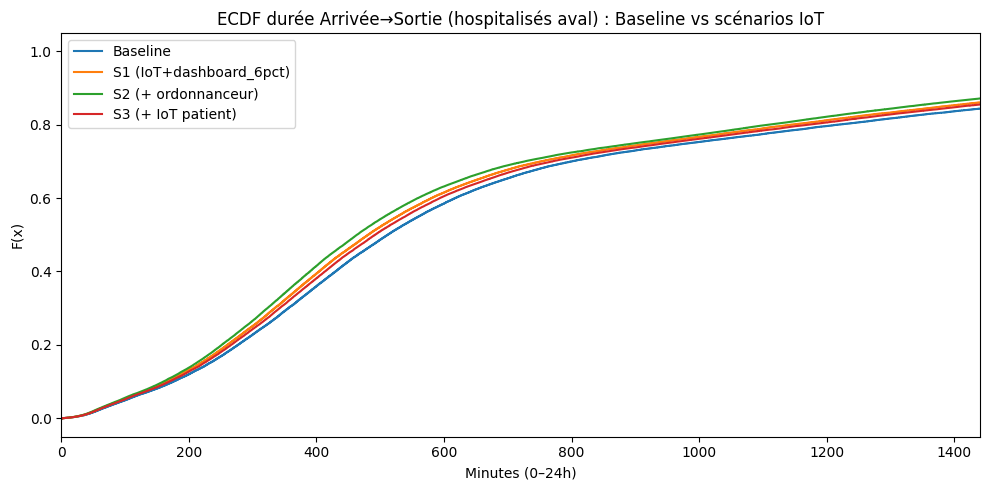

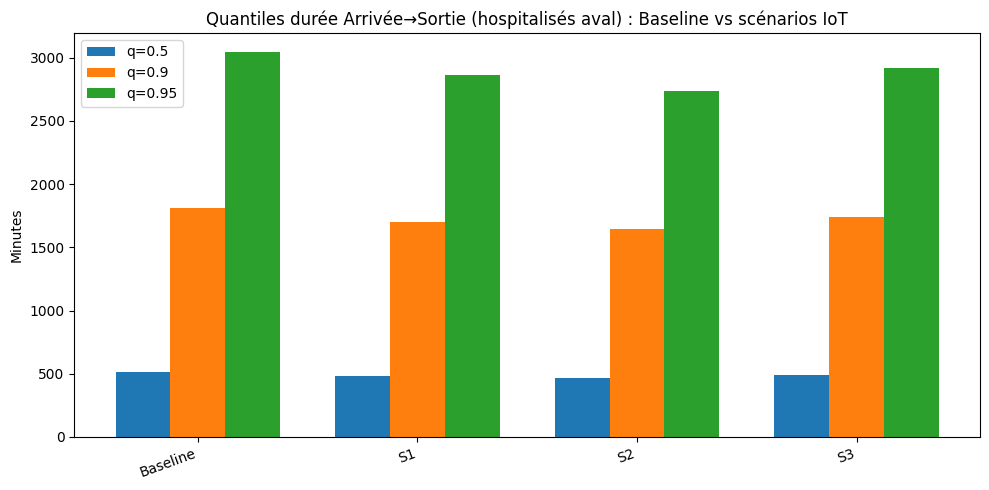

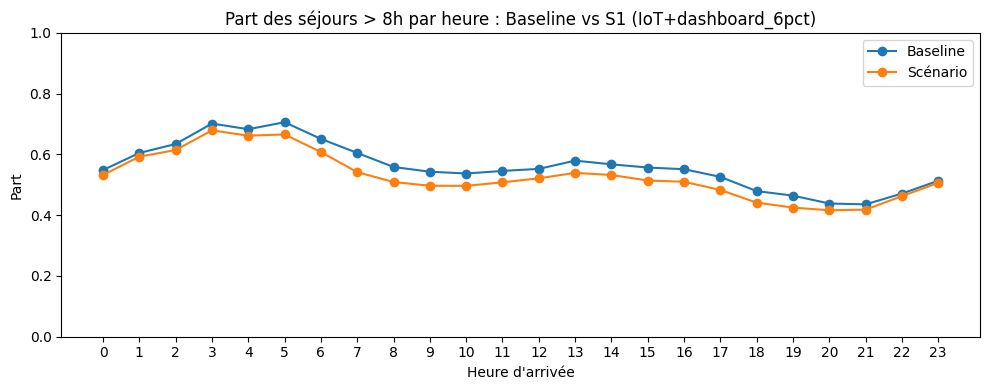

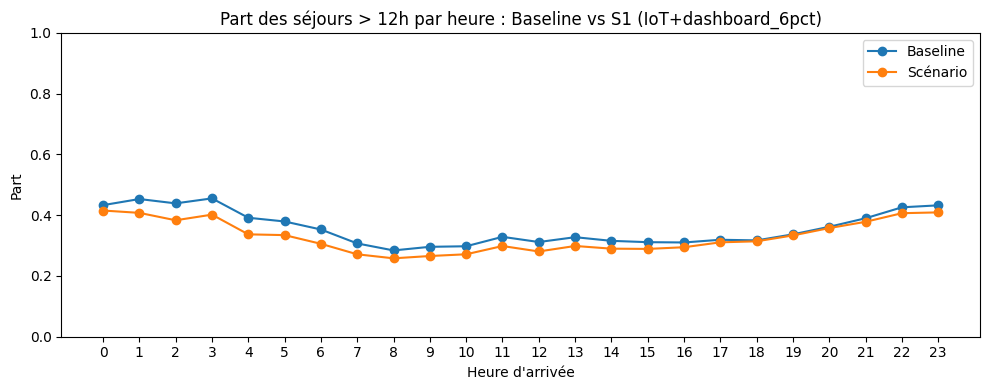

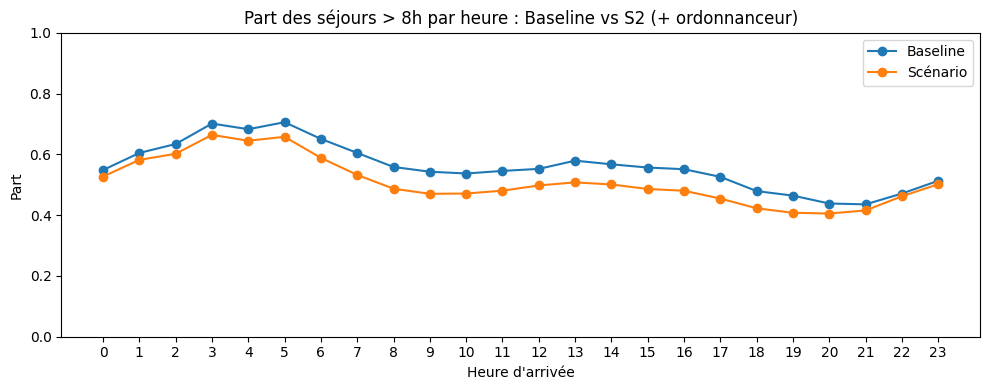

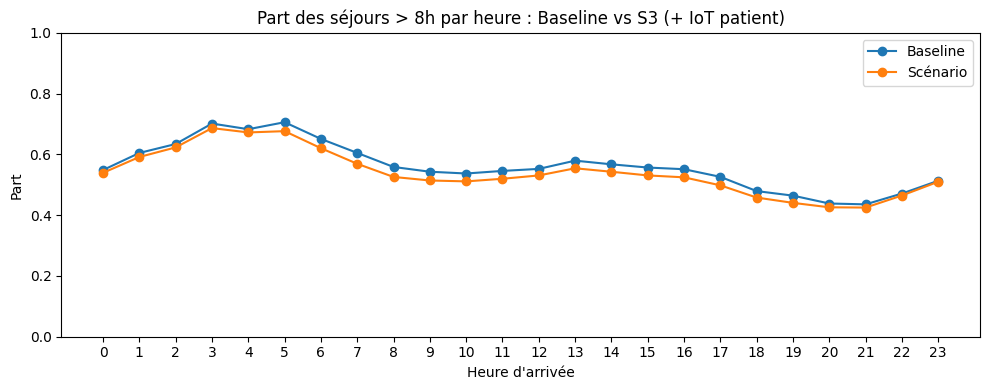

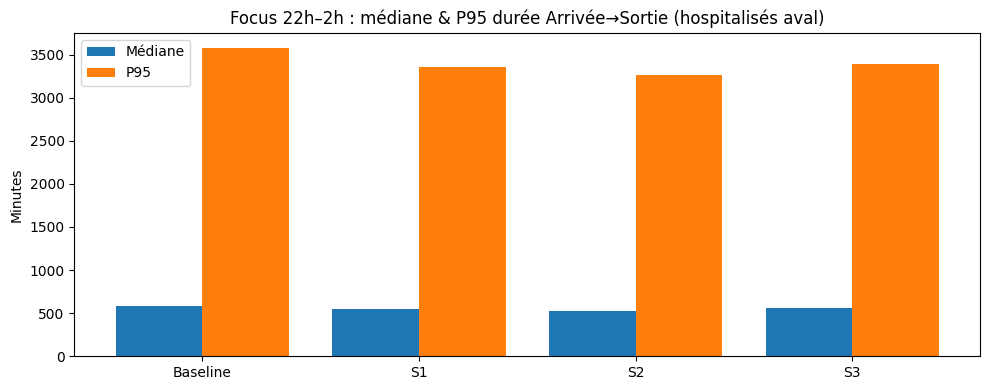

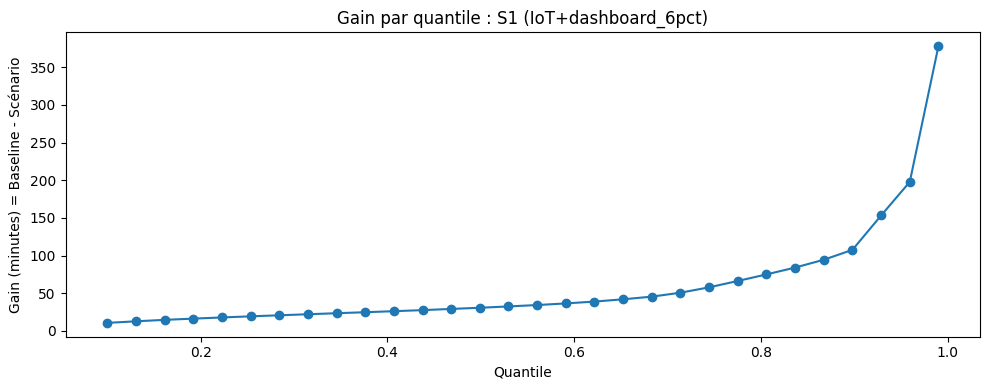

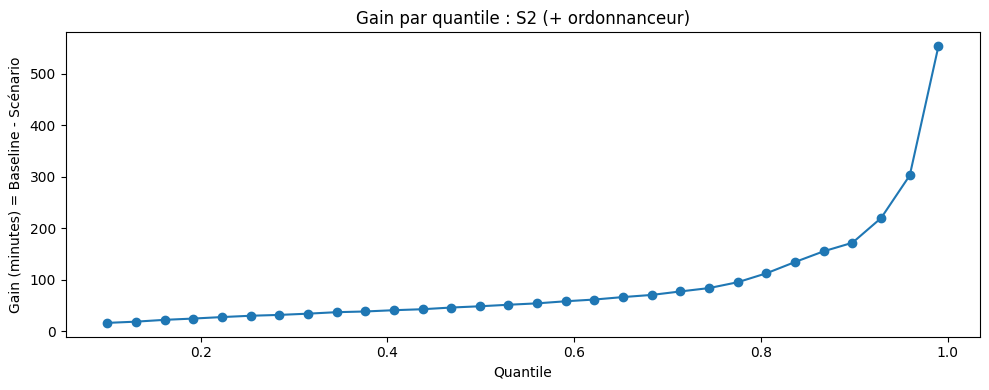

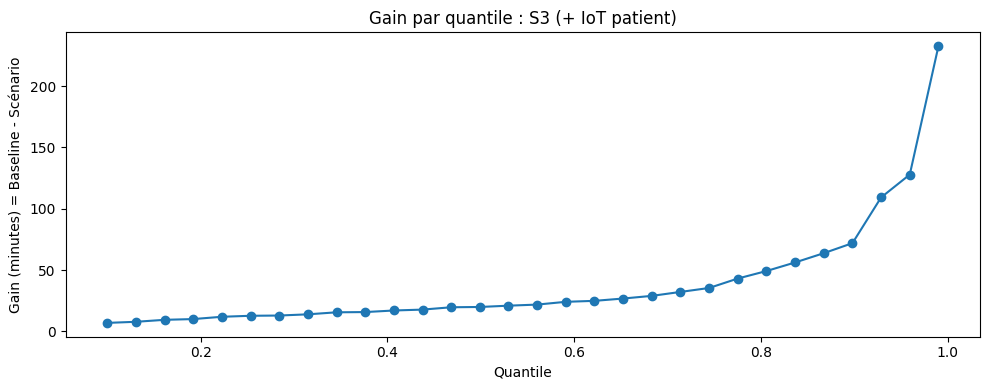

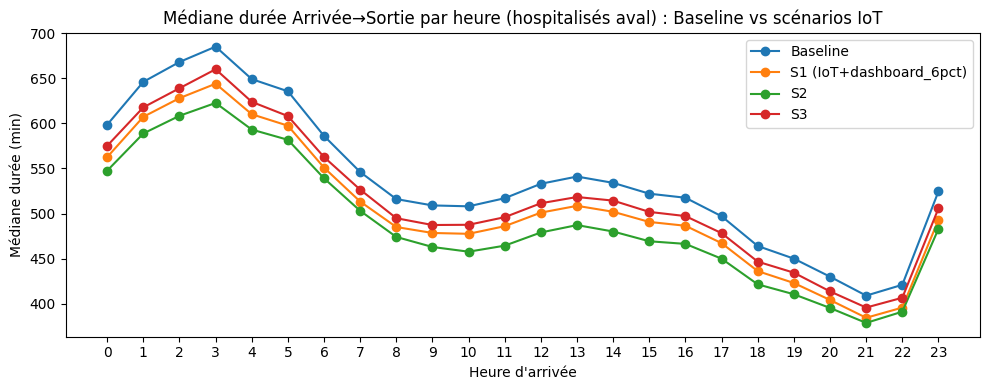

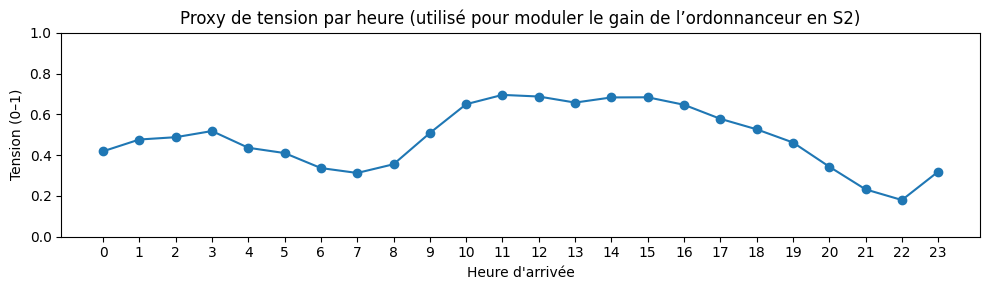

In [ ]:
# ============================================================
# VISUS COMMUNS (S0 vs S1 vs S2 vs S3) — VERSION COHÉRENTE AVEC LES GAINS %
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Pré-requis : s’assurer que les séries sont ALIGNÉES
# ------------------------------------------------------------

df_vis = pd.DataFrame(index=d.index)
df_vis["hour"] = d["hour"]
df_vis["base"] = d["t_arrive_sortie_min"]

# ---- S1 : dans notre version % on a stocké les scénarios dans sim_s1 dict
S1_NAME = "IoT+dashboard_6pct"

# IMPORTANT : sim_s1[S1_NAME] doit contenir "t_arrive_sortie_min_iot" et être sur le même index que d
df_vis["s1"] = sim_s1[S1_NAME]["t_arrive_sortie_min_iot"].reindex(df_vis.index)

# ---- S2 : doit contenir "t_arrive_sortie_min_iot_sched"
df_vis["s2"] = sim_s2["t_arrive_sortie_min_iot_sched"].reindex(df_vis.index)

# ---- S3 : dans S3 on a p (dataframe) avec "t_arrive_sortie_min_iot_patient"
# p n'a pas forcément le même index que d -> on réindexe.
df_vis["s3"] = p["t_arrive_sortie_min_iot_patient"].reindex(df_vis.index)

# On garde seulement les lignes où on a tout (base + s1 + s2 + s3)
df_vis_all = df_vis.dropna(subset=["base", "s1", "s2", "s3"]).copy()

print("Nb lignes alignées pour comparaison S0/S1/S2/S3:", len(df_vis_all))

# ------------------------------------------------------------
# 1) Utilitaires de plots
# ------------------------------------------------------------
def sample_series(s, n=250_000, seed=42):
    s = s.dropna()
    if len(s) > n:
        return s.sample(n=n, random_state=seed)
    return s

def plot_ecdf(series_dict, xlim=None, title="", xlabel="Minutes"):
    plt.figure(figsize=(10, 5))
    for label, s in series_dict.items():
        s = sample_series(pd.Series(s))
        x = np.sort(s.values)
        y = np.arange(1, len(x) + 1) / len(x)
        plt.plot(x, y, label=label)
    if xlim:
        plt.xlim(*xlim)
    plt.xlabel(xlabel)
    plt.ylabel("F(x)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_quantiles(series_dict, quantiles=(0.5, 0.9, 0.95), title="Quantiles", ylabel="Minutes"):
    labels = list(series_dict.keys())
    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(10, 5))
    for i, q in enumerate(quantiles):
        vals = [pd.Series(series_dict[l]).dropna().quantile(q) for l in labels]
        plt.bar(x + (i - 1) * width, vals, width=width, label=f"q={q}")
    plt.xticks(x, labels, rotation=20, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_share_over_threshold_by_hour(df_hour, col_base, col_scn, threshold_min, title):
    dloc = df_hour[["hour", col_base, col_scn]].dropna()

    dloc = dloc.copy()
    dloc["hour"] = dloc["hour"].astype(int)

    g0 = dloc.groupby("hour")[col_base].apply(lambda x: (x > threshold_min).mean())
    g1 = dloc.groupby("hour")[col_scn].apply(lambda x: (x > threshold_min).mean())

    plt.figure(figsize=(10, 4))
    plt.plot(g0.index, g0.values, marker="o", label="Baseline")
    plt.plot(g1.index, g1.values, marker="o", label="Scénario")
    plt.xticks(range(0, 24))
    plt.ylim(0, 1)
    plt.xlabel("Heure d'arrivée")
    plt.ylabel("Part")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_gain_by_quantile(base, scen, qs=np.linspace(0.1, 0.99, 30), title="Gain par quantile"):
    base = pd.Series(base).dropna()
    scen = pd.Series(scen).dropna()

    q_base = np.array([base.quantile(q) for q in qs])
    q_scen = np.array([scen.quantile(q) for q in qs])
    gain = q_base - q_scen

    plt.figure(figsize=(10, 4))
    plt.plot(qs, gain, marker="o")
    plt.xlabel("Quantile")
    plt.ylabel("Gain (minutes) = Baseline - Scénario")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_median_by_hour(df_hour, cols, title):
    # cols = dict label -> column name
    dloc = df_hour[["hour"] + list(cols.values())].dropna().copy()
    dloc["hour"] = dloc["hour"].astype(int)

    plt.figure(figsize=(10, 4))
    for label, col in cols.items():
        g = dloc.groupby("hour")[col].median()
        plt.plot(g.index, g.values, marker="o", label=label)

    plt.xticks(range(0, 24))
    plt.xlabel("Heure d'arrivée")
    plt.ylabel("Médiane durée (min)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 2) Séries alignées (hospitalisés aval)
# ------------------------------------------------------------
base = df_vis_all["base"]
s1   = df_vis_all["s1"]
s2   = df_vis_all["s2"]
s3   = df_vis_all["s3"]

xlim_24h = (0, 24 * 60)

# ------------------------------------------------------------
# 3) ECDF (0–24h)
# ------------------------------------------------------------
plot_ecdf(
    {
        "Baseline": base,
        f"S1 ({S1_NAME})": s1,
        "S2 (+ ordonnanceur)": s2,
        "S3 (+ IoT patient)": s3,
    },
    xlim=xlim_24h,
    title="ECDF durée Arrivée→Sortie (hospitalisés aval) : Baseline vs scénarios IoT",
    xlabel="Minutes (0–24h)"
)

# ------------------------------------------------------------
# 4) Quantiles (médiane, p90, p95)
# ------------------------------------------------------------
plot_quantiles(
    {"Baseline": base, "S1": s1, "S2": s2, "S3": s3},
    quantiles=(0.5, 0.9, 0.95),
    title="Quantiles durée Arrivée→Sortie (hospitalisés aval) : Baseline vs scénarios IoT",
    ylabel="Minutes"
)

# ------------------------------------------------------------
# 5) % séjours longs par heure : >8h et >12h (S1 vs baseline)
# ------------------------------------------------------------
plot_share_over_threshold_by_hour(
    df_vis_all, "base", "s1", threshold_min=8*60,
    title=f"Part des séjours > 8h par heure : Baseline vs S1 ({S1_NAME})"
)

plot_share_over_threshold_by_hour(
    df_vis_all, "base", "s1", threshold_min=12*60,
    title=f"Part des séjours > 12h par heure : Baseline vs S1 ({S1_NAME})"
)
plot_share_over_threshold_by_hour(
    df_vis_all, "base", "s2", threshold_min=8*60,
    title="Part des séjours > 8h par heure : Baseline vs S2 (+ ordonnanceur)"
)
plot_share_over_threshold_by_hour(
    df_vis_all, "base", "s3", threshold_min=8*60,
    title="Part des séjours > 8h par heure : Baseline vs S3 (+ IoT patient)"
)

# ------------------------------------------------------------
# 6) Focus 22h–2h : médiane & P95 (Baseline vs S1/S2/S3)
# ------------------------------------------------------------
peak_hours = [22, 23, 0, 1, 2]
df_peak = df_vis_all[df_vis_all["hour"].isin(peak_hours)].copy()

labels = ["Baseline", "S1", "S2", "S3"]
meds = [
    df_peak["base"].median(),
    df_peak["s1"].median(),
    df_peak["s2"].median(),
    df_peak["s3"].median(),
]
p95s = [
    df_peak["base"].quantile(0.95),
    df_peak["s1"].quantile(0.95),
    df_peak["s2"].quantile(0.95),
    df_peak["s3"].quantile(0.95),
]

plt.figure(figsize=(10, 4))
x = np.arange(len(labels))
plt.bar(x - 0.2, meds, width=0.4, label="Médiane")
plt.bar(x + 0.2, p95s, width=0.4, label="P95")
plt.xticks(x, labels)
plt.ylabel("Minutes")
plt.title("Focus 22h–2h : médiane & P95 durée Arrivée→Sortie (hospitalisés aval)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Gain par quantile (effet sur la queue)
# ------------------------------------------------------------
plot_gain_by_quantile(base, s1, title=f"Gain par quantile : S1 ({S1_NAME})")
plot_gain_by_quantile(base, s2, title="Gain par quantile : S2 (+ ordonnanceur)")
plot_gain_by_quantile(base, s3, title="Gain par quantile : S3 (+ IoT patient)")

# ------------------------------------------------------------
# 8) BONUS : Médiane par heure (très parlant pour le CHU Lille)
# ------------------------------------------------------------
# Conseil : montre la baisse des médianes surtout aux heures tendues.
plot_median_by_hour(
    df_vis_all,
    cols={
        "Baseline": "base",
        f"S1 ({S1_NAME})": "s1",
        "S2": "s2",
        "S3": "s3",
    },
    title="Médiane durée Arrivée→Sortie par heure (hospitalisés aval) : Baseline vs scénarios IoT"
)

# ------------------------------------------------------------
# 9) Courbe de tension 
# ------------------------------------------------------------
# Ici, on la reconstruit depuis sim_s2 pour être autonome.
if "tension_0_1" in sim_s2.columns:
    tens = sim_s2[["hour", "tension_0_1"]].dropna().copy()
    tens["hour"] = tens["hour"].astype(int)
    g_t = tens.groupby("hour")["tension_0_1"].median()

    plt.figure(figsize=(10, 3))
    plt.plot(g_t.index, g_t.values, marker="o")
    plt.xticks(range(0, 24))
    plt.ylim(0, 1)
    plt.xlabel("Heure d'arrivée")
    plt.ylabel("Tension (0–1)")
    plt.title("Proxy de tension par heure (utilisé pour moduler le gain de l’ordonnanceur en S2)")
    plt.tight_layout()
    plt.show()

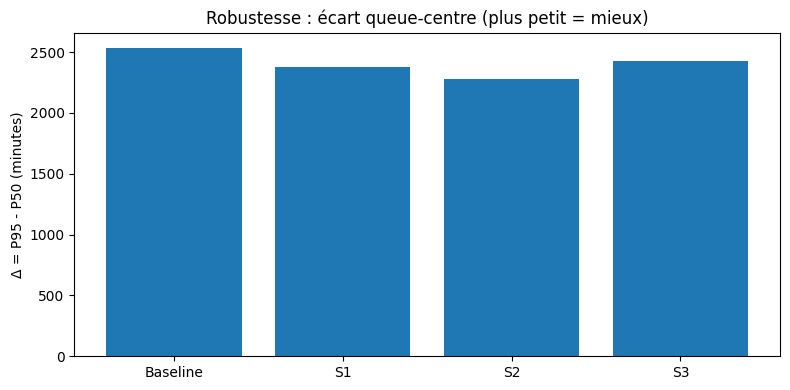

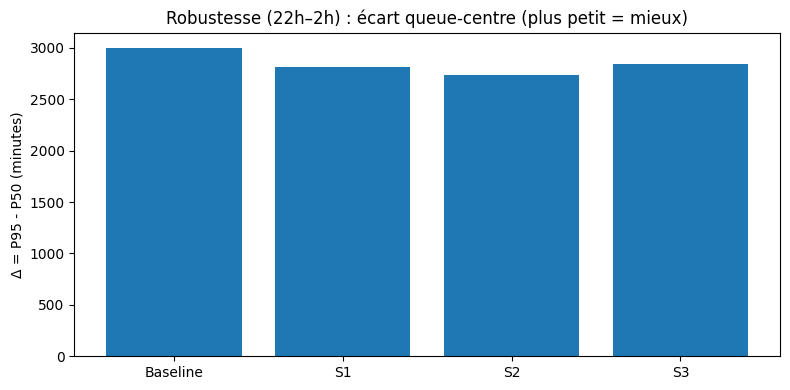

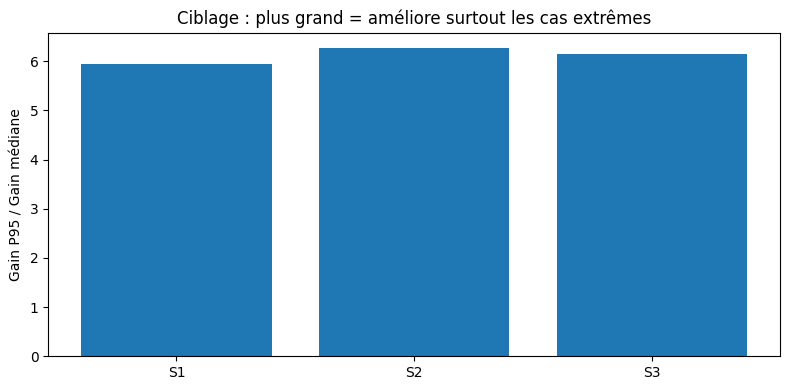

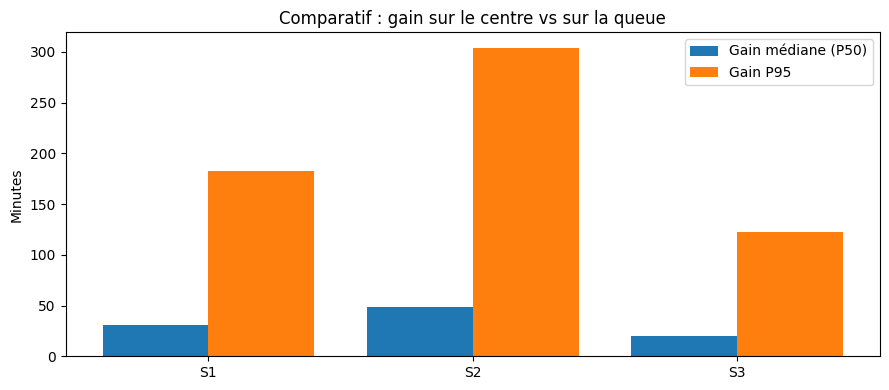

/var/folders/1x/rzpvcrbd5jj7cgj4c0qm20k40000gn/T/ipykernel_26927/807051648.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = dloc.groupby("tbin")[tens_col].mean()
/var/folders/1x/rzpvcrbd5jj7cgj4c0qm20k40000gn/T/ipykernel_26927/807051648.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = dloc.assign(gain=gain).groupby("tbin")["gain"].mean()
/var/folders/1x/rzpvcrbd5jj7cgj4c0qm20k40000gn/T/ipykernel_26927/807051648.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or o

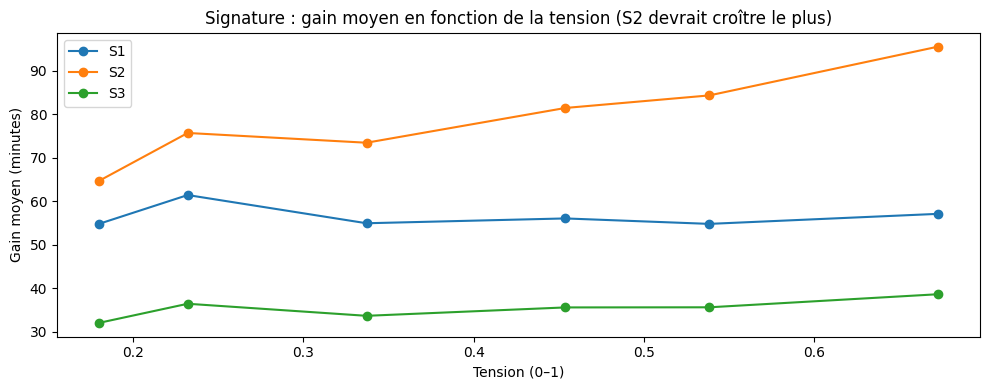

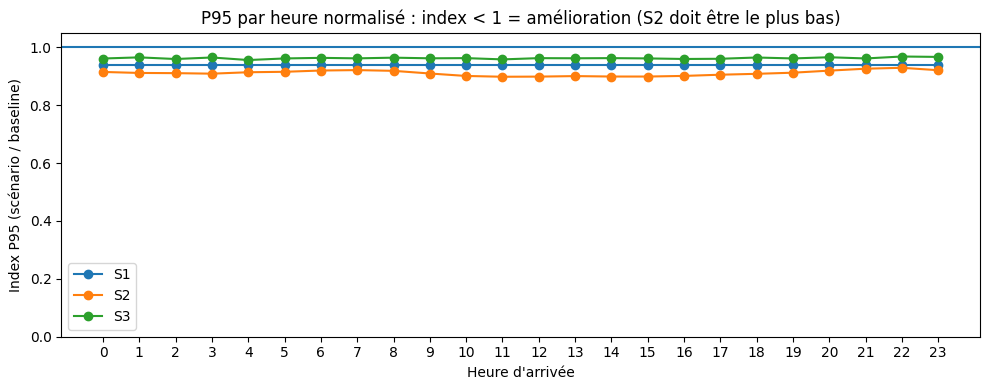

/var/folders/1x/rzpvcrbd5jj7cgj4c0qm20k40000gn/T/ipykernel_26927/807051648.py:203: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y.values, dx=1.0))


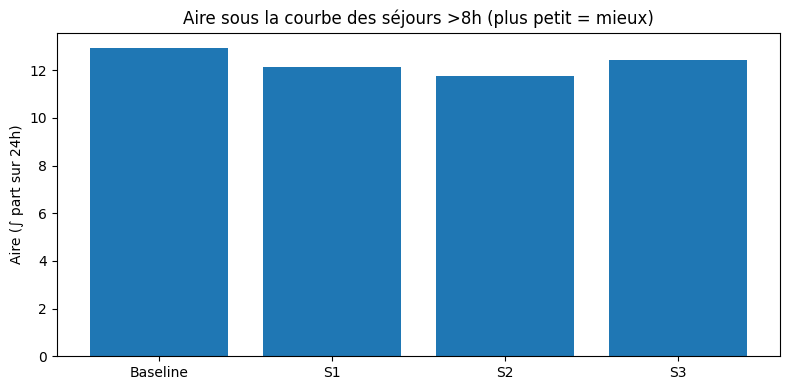

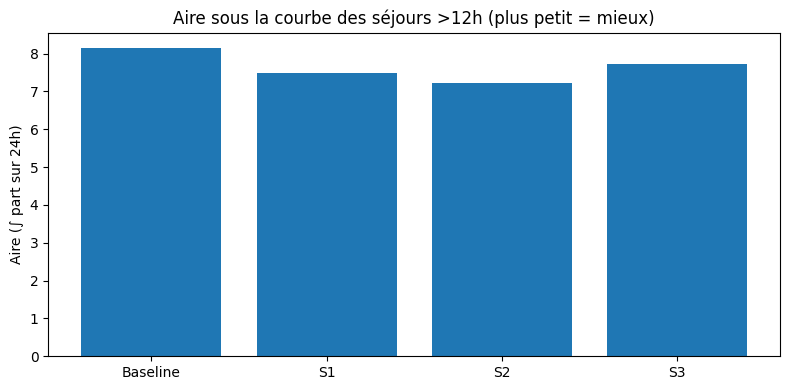

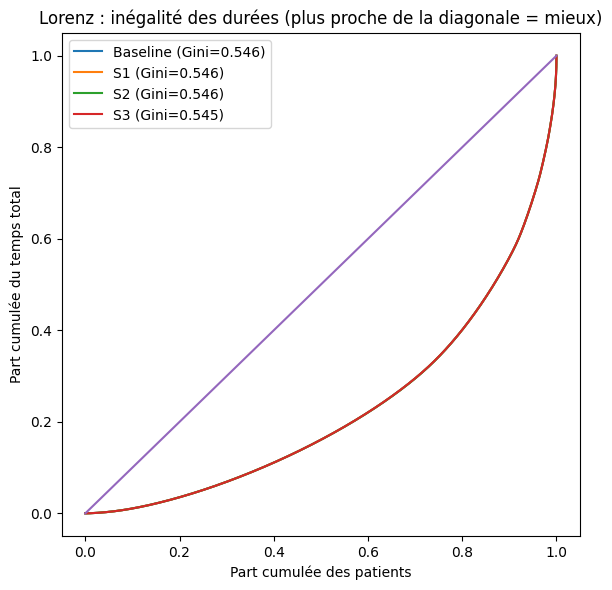

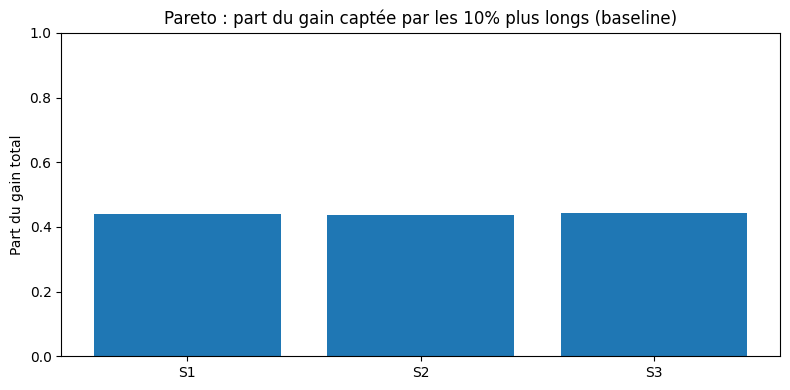

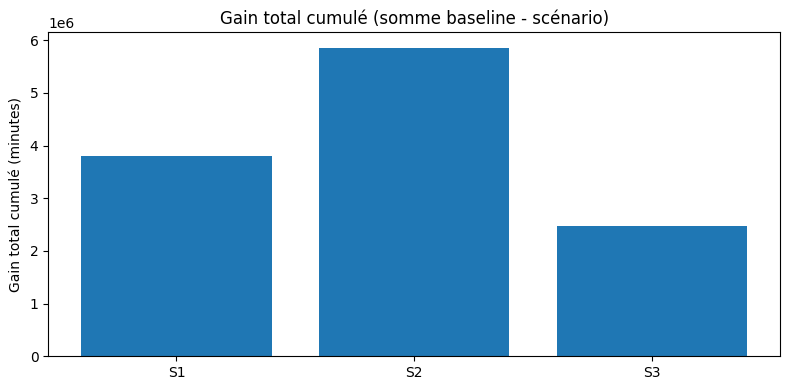

In [14]:
# ============================================================
# VISUS BONUS "S2 est le meilleur" — AJOUTS
# (à coller APRÈS la construction de df_vis_all)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Récupérer / reconstruire une tension (0-1) par heure
# ----------------------------
def normalize_0_1(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

def build_tension_from_dfvis(df: pd.DataFrame, mode="mix", alpha=0.5) -> pd.Series:
    """
    Tension horaire 0-1 construite depuis df_vis_all (baseline).
    - counts: volume par heure
    - los: médiane baseline par heure
    - mix: alpha*counts + (1-alpha)*los
    Renvoie une série indexée par hour (0..23).
    """
    hour_counts = df.groupby("hour").size()
    hour_median_los = df.groupby("hour")["base"].median()

    t_counts = normalize_0_1(hour_counts)
    t_los = normalize_0_1(hour_median_los)

    if mode == "counts":
        tension = t_counts
    elif mode == "los":
        tension = t_los
    elif mode == "mix":
        tension = alpha * t_counts + (1 - alpha) * t_los
    else:
        raise ValueError("mode must be counts/los/mix")

    return tension.clip(0, 1)

# Si tu as tension_0_1 dans sim_s2, on l'utilise.
# Sinon, on reconstruit une tension "mix" depuis df_vis_all.
if "tension_0_1" in sim_s2.columns:
    tens_map = (sim_s2[["hour","tension_0_1"]]
                .dropna()
                .assign(hour=lambda x: x["hour"].astype(int))
                .groupby("hour")["tension_0_1"].median())
else:
    tens_map = build_tension_from_dfvis(df_vis_all, mode="mix", alpha=0.5)

df_vis_all = df_vis_all.copy()
df_vis_all["hour"] = df_vis_all["hour"].astype(int)
df_vis_all["tension_0_1"] = df_vis_all["hour"].map(tens_map).fillna(0.0)

# Séries
base = df_vis_all["base"]
s1   = df_vis_all["s1"]
s2   = df_vis_all["s2"]
s3   = df_vis_all["s3"]

# ============================================================
# 1) ROBUSTESSE : Delta = P95 - P50 (global + focus 22-2)
# ============================================================
def delta_p95_p50(x):
    x = pd.Series(x).dropna()
    return float(x.quantile(0.95) - x.quantile(0.50))

labels = ["Baseline", "S1", "S2", "S3"]
deltas = [delta_p95_p50(base), delta_p95_p50(s1), delta_p95_p50(s2), delta_p95_p50(s3)]

plt.figure(figsize=(8,4))
plt.bar(np.arange(len(labels)), deltas)
plt.xticks(np.arange(len(labels)), labels)
plt.ylabel("Δ = P95 - P50 (minutes)")
plt.title("Robustesse : écart queue-centre (plus petit = mieux)")
plt.tight_layout()
plt.show()

# Focus 22h-2h
peak_hours = [22, 23, 0, 1, 2]
df_peak = df_vis_all[df_vis_all["hour"].isin(peak_hours)].copy()

base_p = df_peak["base"]; s1_p = df_peak["s1"]; s2_p = df_peak["s2"]; s3_p = df_peak["s3"]
deltas_peak = [delta_p95_p50(base_p), delta_p95_p50(s1_p), delta_p95_p50(s2_p), delta_p95_p50(s3_p)]

plt.figure(figsize=(8,4))
plt.bar(np.arange(len(labels)), deltas_peak)
plt.xticks(np.arange(len(labels)), labels)
plt.ylabel("Δ = P95 - P50 (minutes)")
plt.title("Robustesse (22h–2h) : écart queue-centre (plus petit = mieux)")
plt.tight_layout()
plt.show()


# ============================================================
# 2) CIBLAGE : ratio = Gain_P95 / Gain_Médiane (>>1 = agit sur la crise)
# ============================================================
def gain_quantile(base, scen, q):
    b = pd.Series(base).dropna().quantile(q)
    s = pd.Series(scen).dropna().quantile(q)
    return float(b - s)

def ratio_gain_p95_over_median(base, scen):
    g50 = gain_quantile(base, scen, 0.50)
    g95 = gain_quantile(base, scen, 0.95)
    return g95 / (g50 + 1e-9), g50, g95

ratios = []
g50s, g95s = [], []
for scen in [s1, s2, s3]:
    r, g50, g95 = ratio_gain_p95_over_median(base, scen)
    ratios.append(r); g50s.append(g50); g95s.append(g95)

plt.figure(figsize=(8,4))
plt.bar([1,2,3], ratios)
plt.xticks([1,2,3], ["S1","S2","S3"])
plt.ylabel("Gain P95 / Gain médiane")
plt.title("Ciblage : plus grand = améliore surtout les cas extrêmes")
plt.tight_layout()
plt.show()

# (option) afficher gains P50 et P95 à côté
plt.figure(figsize=(9,4))
x = np.arange(3)
plt.bar(x-0.2, g50s, width=0.4, label="Gain médiane (P50)")
plt.bar(x+0.2, g95s, width=0.4, label="Gain P95")
plt.xticks(x, ["S1","S2","S3"])
plt.ylabel("Minutes")
plt.title("Comparatif : gain sur le centre vs sur la queue")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 3) SIGNATURE S2 : Gain moyen vs tension (bins)
# ============================================================
def plot_gain_vs_tension_bins(df, base_col="base", scen_cols=("s1","s2","s3"),
                              tens_col="tension_0_1", nbins=10, title="Gain vs tension"):
    dloc = df[[base_col, tens_col] + list(scen_cols)].dropna().copy()
    # bins de tension
    dloc["tbin"] = pd.cut(dloc[tens_col], bins=np.linspace(0,1,nbins+1), include_lowest=True)
    centers = dloc.groupby("tbin")[tens_col].mean()

    plt.figure(figsize=(10,4))
    for c in scen_cols:
        gain = (dloc[base_col] - dloc[c]).clip(lower=0)
        g = dloc.assign(gain=gain).groupby("tbin")["gain"].mean()
        plt.plot(centers.values, g.values, marker="o", label=c.upper())
    plt.xlabel("Tension (0–1)")
    plt.ylabel("Gain moyen (minutes)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_gain_vs_tension_bins(
    df_vis_all,
    title="Signature : gain moyen en fonction de la tension (S2 devrait croître le plus)"
)


# ============================================================
# 4) P95 par heure : Index = P95_scn / P95_base (<1 = mieux)
# ============================================================
def p95_by_hour(df, col):
    return df.groupby("hour")[col].apply(lambda x: pd.Series(x).dropna().quantile(0.95))

p95_base_h = p95_by_hour(df_vis_all, "base")
p95_s1_h   = p95_by_hour(df_vis_all, "s1")
p95_s2_h   = p95_by_hour(df_vis_all, "s2")
p95_s3_h   = p95_by_hour(df_vis_all, "s3")

idx_s1 = (p95_s1_h / (p95_base_h + 1e-9))
idx_s2 = (p95_s2_h / (p95_base_h + 1e-9))
idx_s3 = (p95_s3_h / (p95_base_h + 1e-9))

plt.figure(figsize=(10,4))
plt.plot(idx_s1.index, idx_s1.values, marker="o", label="S1")
plt.plot(idx_s2.index, idx_s2.values, marker="o", label="S2")
plt.plot(idx_s3.index, idx_s3.values, marker="o", label="S3")
plt.axhline(1.0)
plt.xticks(range(0,24))
plt.ylim(0, max(1.05, float(np.nanmax([idx_s1.max(), idx_s2.max(), idx_s3.max()])) + 0.05))
plt.xlabel("Heure d'arrivée")
plt.ylabel("Index P95 (scénario / baseline)")
plt.title("P95 par heure normalisé : index < 1 = amélioration (S2 doit être le plus bas)")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 5) AIRE sous la courbe des séjours > Xh (sur 24h) : plus petit = mieux
# ============================================================
def share_over_by_hour(df, col, thr):
    return df.groupby("hour")[col].apply(lambda x: (pd.Series(x).dropna() > thr).mean())

def area_curve(y):
    # y indexé par heure 0..23 ; aire approximée par somme (pas=1h)
    y = y.reindex(range(0,24)).fillna(0.0)
    return float(np.trapz(y.values, dx=1.0))

thr8  = 8*60
thr12 = 12*60

areas = {}
for thr, name in [(thr8, ">8h"), (thr12, ">12h")]:
    base_h = share_over_by_hour(df_vis_all, "base", thr)
    s1_h   = share_over_by_hour(df_vis_all, "s1", thr)
    s2_h   = share_over_by_hour(df_vis_all, "s2", thr)
    s3_h   = share_over_by_hour(df_vis_all, "s3", thr)
    areas[name] = {
        "Baseline": area_curve(base_h),
        "S1": area_curve(s1_h),
        "S2": area_curve(s2_h),
        "S3": area_curve(s3_h),
    }

for name, dct in areas.items():
    plt.figure(figsize=(8,4))
    labs = list(dct.keys()); vals = list(dct.values())
    plt.bar(np.arange(len(labs)), vals)
    plt.xticks(np.arange(len(labs)), labs)
    plt.ylabel("Aire (∫ part sur 24h)")
    plt.title(f"Aire sous la courbe des séjours {name} (plus petit = mieux)")
    plt.tight_layout()
    plt.show()


# ============================================================
# 6) BONUS : Courbe de Lorenz + Gini (inégalité des durées)
# ============================================================
def lorenz_curve(x):
    x = np.sort(pd.Series(x).dropna().values)
    if len(x) == 0:
        return np.array([0,1]), np.array([0,1])
    cum = np.cumsum(x)
    cum = np.insert(cum, 0, 0)
    cum = cum / cum[-1]
    p = np.linspace(0, 1, len(cum))
    return p, cum

def gini(x):
    x = np.sort(pd.Series(x).dropna().values)
    n = len(x)
    if n == 0:
        return np.nan
    cumx = np.cumsum(x)
    return (n + 1 - 2*np.sum(cumx)/cumx[-1]) / n

plt.figure(figsize=(6,6))
for lab, s in {"Baseline": base, "S1": s1, "S2": s2, "S3": s3}.items():
    p_l, L = lorenz_curve(s)
    plt.plot(p_l, L, label=f"{lab} (Gini={gini(s):.3f})")
plt.plot([0,1],[0,1])
plt.xlabel("Part cumulée des patients")
plt.ylabel("Part cumulée du temps total")
plt.title("Lorenz : inégalité des durées (plus proche de la diagonale = mieux)")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 7) BONUS : Part du gain total captée par les 10% plus longs (Pareto)
# ============================================================
def pareto_gain_share(base, scen, top_frac=0.10):
    base = pd.Series(base).dropna()
    scen = pd.Series(scen).dropna()
    n = min(len(base), len(scen))
    base = base.iloc[:n].reset_index(drop=True)
    scen = scen.iloc[:n].reset_index(drop=True)

    gain = (base - scen).clip(lower=0)
    # top_frac des plus longs (baseline)
    thr = base.quantile(1 - top_frac)
    mask = base >= thr
    share = gain[mask].sum() / (gain.sum() + 1e-9)
    return float(share), float(gain.sum())

shares = {}
totals = {}
for lab, scen in {"S1": s1, "S2": s2, "S3": s3}.items():
    sh, tot = pareto_gain_share(base, scen, top_frac=0.10)
    shares[lab] = sh
    totals[lab] = tot

plt.figure(figsize=(8,4))
plt.bar(np.arange(3), [shares["S1"], shares["S2"], shares["S3"]])
plt.xticks(np.arange(3), ["S1","S2","S3"])
plt.ylim(0,1)
plt.ylabel("Part du gain total")
plt.title("Pareto : part du gain captée par les 10% plus longs (baseline)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(np.arange(3), [totals["S1"], totals["S2"], totals["S3"]])
plt.xticks(np.arange(3), ["S1","S2","S3"])
plt.ylabel("Gain total cumulé (minutes)")
plt.title("Gain total cumulé (somme baseline - scénario)")
plt.tight_layout()
plt.show()